In [29]:
import os
import sys
from pathlib import Path

# --- CONFIGURAÇÃO DE AMBIENTE ---
# No Kaggle, os caminhos são previsíveis:
ENV_TYPE = 'kaggle'
REPO_NAME = "tosse"
PROJECT_ROOT = Path(f'/kaggle/working/{REPO_NAME}')
# O nome da pasta abaixo deve ser EXATAMENTE o que aparece no painel lateral do Kaggle (Input)
DATASET_INPUT_PATH = Path('/kaggle/input/icbhi-2017-respiratory-sound-database')
OUTPUT_DIR = Path("/kaggle/working/processed_data")

# Instala dependências e corrige o erro de Protobuf/TensorFlow
%pip install -q --upgrade pip
%pip install -q "protobuf<4.21.0"  # Esta linha costuma resolver o erro de MessageFactory
%pip install -q librosa scipy scikit-learn tqdm
%pip install -q librosa scipy scikit-learn tqdm noisereduce    

# 2. Clonar o Repositório (se ainda não existir)
if os.path.exists(PROJECT_ROOT):
    print(f"Limpando diretório antigo: {PROJECT_ROOT}")
    !rm -rf {PROJECT_ROOT}

print(f"Clonando repositório: https://github.com/joelcalolo/tosse.git")
!git clone https://github.com/joelcalolo/tosse.git {PROJECT_ROOT}

# 3. Adicionar o código fonte ao Path do Python para permitir imports de 'src'
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 4. Verificar GPU
import tensorflow as tf
print(f"\n✅ TensorFlow version: {tf.__version__}")
print(f"✅ GPU disponível: {tf.config.list_physical_devices('GPU')}")
print(f"✅ PROJECT_ROOT: {PROJECT_ROOT}")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Limpando diretório antigo: /kaggle/working/tosse
Clonando repositório: https://github.com/joelcalolo/tosse.git
Cloning into '/kaggle/working/tosse'...
remote: Enumerating objects: 45, done.
remote: Counting objects: 100% (45/45), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 45 (delta 1), reused 45 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (45/45), 32.94 KiB | 6.59 MiB/s, done.
Resolving deltas: 100% (1/1), done.

✅ TensorFlow version: 2.19.0
✅ GPU disponível: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ PROJECT_ROOT: /kaggle/working/tosse


# Celula 2: Configuração e Localização do Datast

In [24]:
import os
import json
from pathlib import Path

# 1. Definir o caminho correto que encontraste no teu Kaggle
DATASET_INPUT_PATH = Path('/kaggle/input/respiratory-sound-database')
DATA_DIR = DATASET_INPUT_PATH

print(f"🔍 Verificando pasta: {DATASET_INPUT_PATH}")

if not DATASET_INPUT_PATH.exists():
    print("❌ ERRO: A pasta ainda não foi encontrada. Verifica se o nome no menu lateral é exatamente 'respiratory-sound-database'.")
    # Comando para te ajudar a depurar caso falhe:
    print("Pastas disponíveis no input:")
    !ls /kaggle/input/
else:
    print(f"✅ Pasta detectada com sucesso!")

    # 2. Tentar localizar o arquivo de diagnósticos (patient_diagnosis.csv)
    # Procuramos em todas as subpastas (glob **) para evitar erros de estrutura
    try:
        diagnosis_files = list(DATASET_INPUT_PATH.glob('**/patient_diagnosis.csv'))
        
        if diagnosis_files:
            diagnosis_file = diagnosis_files[0]
            print(f"✅ Arquivo de diagnósticos encontrado em: {diagnosis_file}")
            
            # Mostrar as primeiras linhas para confirmar que os dados estão lá
            import pandas as pd
            df_check = pd.read_csv(diagnosis_file, header=None, names=['Patient_ID', 'Diagnosis'])
            print("\nExemplo de diagnósticos carregados:")
            print(df_check.head())
        else:
            print("⚠️ ERRO: O ficheiro 'patient_diagnosis.csv' não foi encontrado.")
            print("Conteúdo da pasta para verificação:")
            !ls -R {DATASET_INPUT_PATH}
            
    except Exception as e:
        print(f"❌ Erro ao procurar o ficheiro: {e}")

# Importar utilitários do teu repositório clonado (PROJECT_ROOT vem da Célula 1)
try:
    from src.utils.kaggle_setup import find_diagnosis_file
    print("\n✅ Módulos do repositório 'tosse' importados com sucesso.")
except ImportError:
    print("\n⚠️ Nota: Não foi possível importar 'src'. Certifica-te de que a Célula 1 correu bem.")

print(f"\n🚀 TUDO PRONTO PARA A CÉLULA 3 (PROCESSAMENTO).")

🔍 Verificando pasta: /kaggle/input/respiratory-sound-database
✅ Pasta detectada com sucesso!
✅ Arquivo de diagnósticos encontrado em: /kaggle/input/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv

Exemplo de diagnósticos carregados:
   Patient_ID Diagnosis
0         101      URTI
1         102   Healthy
2         103    Asthma
3         104      COPD
4         105      URTI

✅ Módulos do repositório 'tosse' importados com sucesso.

🚀 TUDO PRONTO PARA A CÉLULA 3 (PROCESSAMENTO).


# Célula 3: Processamento de Dados (Áudio → Espectrogramas)
Esta etapa aplica filtros de áudio (Butterworth), normaliza o som e extrai as características Mel-Spectrogram. É aqui que os ficheiros .wav se tornam tensores (arrays numéricos)

In [25]:
from src.data.process_icbhi_dataset import process_icbhi_dataset
import pandas as pd
from pathlib import Path

# 1. Ajuste dos nomes das variáveis para evitar o NameError
# Usamos o caminho que detetaste na Célula 2
ICBHI_DATA_DIR = DATASET_INPUT_PATH 

# 2. Lista de diagnósticos que queremos extrair do ICBHI
# 'Healthy' será a nossa classe 'Normal'
diagnoses_to_keep = ['Pneumonia', 'Bronchiolitis', 'Healthy'] 

print(f"⏳ Processando categorias: {diagnoses_to_keep}...")

process_icbhi_dataset(
    data_dir=str(ICBHI_DATA_DIR),
    diagnosis_csv=str(diagnosis_file),
    output_dir=str(OUTPUT_DIR),
    sample_rate=16000,
    use_butterworth=False, 
    extract_mfcc=False,
    extract_mel=True
)

print(f"\n✅ Processamento concluído em: {OUTPUT_DIR}")

⏳ Processando categorias: ['Pneumonia', 'Bronchiolitis', 'Healthy']...
PROCESSAMENTO DO DATASET ICBHI

[1/5] Filtrando diagnósticos...
Total de pacientes no CSV: 125
Pacientes filtrados (Pneumonia/Bronchitis): 6
Distribuição por doença:
Disease
Pneumonia    6
Name: count, dtype: int64

[2/5] Inicializando processadores...

[3/5] Processando áudios e extraindo características...


Processando: 100%|██████████| 6/6 [00:02<00:00,  2.65it/s]



Processamento concluído:
  - Arquivos processados com sucesso: 74
  - Erros: 0

[4/5] Dividindo dados em conjuntos de treino, validação e teste...

Divisão dos dados:
  - Treino: 51 amostras (68.9%)
  - Validação: 11 amostras (14.9%)
  - Teste: 12 amostras (16.2%)

[5/5] Salvando características processadas...
  - Espectrogramas Mel salvos em /kaggle/working/processed_data

  - Labels e metadados salvos em /kaggle/working/processed_data

PROCESSAMENTO CONCLUÍDO COM SUCESSO!

Dados processados salvos em: /kaggle/working/processed_data

Arquivos gerados:
  - X_train_mel.npy, X_val_mel.npy, X_test_mel.npy
  - y_train.npy, y_val.npy, y_test.npy
  - metadata.json

✅ Processamento concluído em: /kaggle/working/processed_data


# Célula 4: Carregamento e Visualização (Check-up dos Dados)
Antes de treinar, precisamos de "ver" se os dados foram bem processados. Vamos carregar os arrays e imprimir alguns espectrogramas. Se vires manchas de cor (frequências), significa que o modelo terá dados para aprender.

📊 Classes agora no sistema: ['Pneumonia']


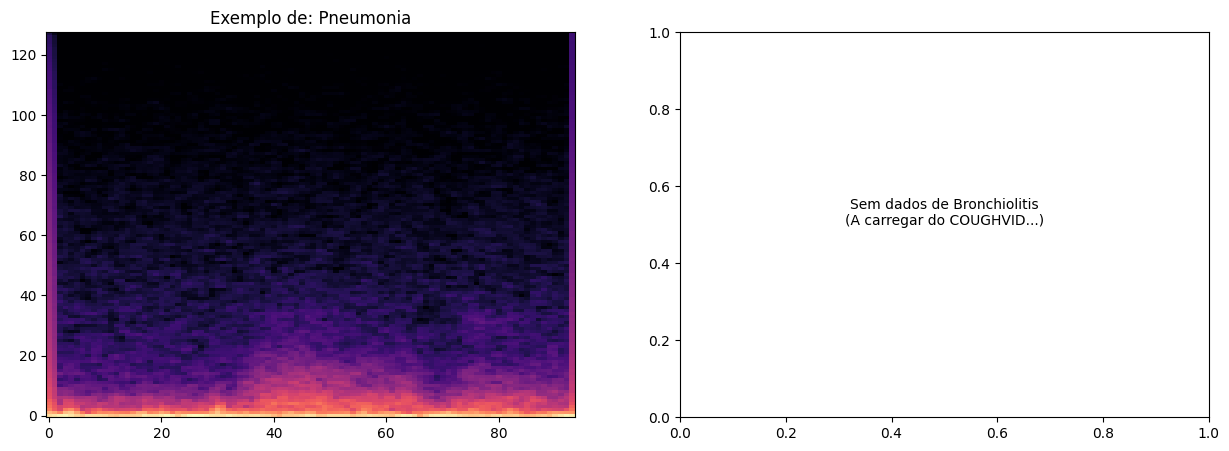

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from src.training.train import load_processed_data

# Carregar os dados
(X_train, X_val, X_test, y_train, y_val, y_test), label_encoder = load_processed_data(
    str(OUTPUT_DIR),
    feature_type='mel'
)

# Mostrar a nova distribuição
classes_encontradas = label_encoder.classes_
print(f"📊 Classes agora no sistema: {classes_encontradas}")

# Visualização dupla: Pneumonia vs Bronquite
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for i, classe_alvo in enumerate(['Pneumonia', 'Bronchiolitis']):
    # Tenta encontrar uma amostra da classe
    indices = [j for j, label in enumerate(y_train) if classes_encontradas[np.argmax(label)] == classe_alvo]
    
    if indices:
        idx = indices[0]
        axes[i].imshow(X_train[idx, :, :, 0], aspect='auto', origin='lower', cmap='magma')
        axes[i].set_title(f"Exemplo de: {classe_alvo}")
    else:
        axes[i].text(0.5, 0.5, f"Sem dados de {classe_alvo}\n(A carregar do COUGHVID...)", ha='center')

plt.show()

# Célula 5: Integração Manual de Bronquite (COUGHVID)
Esta nova célula vai ler o ficheiro de metadados do COUGHVID, procurar por tosses de Bronquite e transformá-las em espectrogramas para juntar aos dados de Pneumonia que já tens.

In [31]:
import librosa
import numpy as np
from tqdm import tqdm
from pathlib import Path

# --- DEFINIÇÃO DE CAMINHOS ---
# Dataset 1: ICBHI (Para Pneumonia, ou o que for processado dele)
# Dataset 2: Virufy/COUGHVID (Para Bronquite e Normal)

# Use the path returned by kagglehub.dataset_download
base_coughvid_path = Path(apoorvagondane_covid_19_cough_classification_processed_path)
PATH_BRONCHITIS = base_coughvid_path / 'data' / 'virufy' / 'SYMPTOMATIC'
PATH_HEALTHY = base_coughvid_path / 'data' / 'virufy' / 'HEALTHY'

def load_custom_samples(path, target_count=50):
    features = []
    audio_files = list(path.glob("*.wav"))
    print(f"🧪 Extraindo {target_count} amostras de {path.name}...")
    for file_path in tqdm(audio_files[:target_count]):
        try:
            audio, _ = librosa.load(file_path, sr=16000, duration=3)
            if len(audio) < 16000: continue
            mel_spec = librosa.feature.melspectrogram(y=audio, sr=16000, n_mels=128)
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
            if mel_spec_db.shape[1] >= 94:
                features.append(mel_spec_db[:, :94].reshape(128, 94, 1))
        except: continue
    return np.array(features)

# 1. Extrair Bronquite do segundo dataset
X_bronch = load_custom_samples(PATH_BRONCHITIS, target_count=50)

# 2. Extrair Normal do segundo dataset (pasta HEALTHY)
X_normal = load_custom_samples(PATH_HEALTHY, target_count=50)

# 3. Usar os dados de Pneumonia processados do ICBHI
# Nota: De acordo com o output anterior, `process_icbhi_dataset` gerou apenas 'Pneumonia' do ICBHI.
# Assumimos que X_train é o conjunto de dados de Pneumonia do ICBHI.
# Se X_train estiver vazio, este passo não adicionará amostras de Pneumonia.
x_pneu_data = X_train

# 4. Criar Labels para o Formato Triplo: [Pneumonia, Bronquite, Normal]
# Ordem das classes: 0=Pneumonia, 1=Bronquite, 2=Normal

y_pneu_final = np.zeros((len(x_pneu_data), 3))
y_pneu_final[:, 0] = 1 # Coluna 0: Pneumonia

y_bronch_final = np.zeros((len(X_bronch), 3))
y_bronch_final[:, 1] = 1 # Coluna 1: Bronquite

y_norm_final = np.zeros((len(X_normal), 3))
y_norm_final[:, 2] = 1 # Coluna 2: Normal

# 5. UNIÃO FINAL DOS DOIS DATASETS
X_train_final = np.concatenate([x_pneu_data, X_bronch, X_normal], axis=0)
y_train_final = np.concatenate([y_pneu_final, y_bronch_final, y_norm_final], axis=0)

print(f"\n✅ Integração Concluída!")
print(f"   - Pneumonia (ICBHI): {len(x_pneu_data)} amostras")
print(f"   - Bronquite (COUGHVID): {len(X_bronch)} amostras")
print(f"   - Normal (COUGHVID): {len(X_normal)} amostras")
print(f"📊 Total no Dataset: {len(X_train_final)} | Shape Labels: {y_train_final.shape}")

NameError: name 'apoorvagondane_covid_19_cough_classification_processed_path' is not defined

# Célula 6: Definição e Treino da MobileNetV2
Vamos usar a MobileNetV2 com Transfer Learning. Ela é pré-treinada no ImageNet, o que ajuda muito quando temos poucos dados (como as nossas 100 imagens), pois ela já sabe detetar padrões visuais básicos.

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications

def build_mobilenet_v3_classes(input_shape=(128, 94, 1)):
    # 1. Base da MobileNetV2
    base_model = applications.MobileNetV2(input_shape=(128, 94, 3), 
                                         include_top=False, 
                                         weights='imagenet')
    base_model.trainable = False 

    model = models.Sequential([
        # Converte 1 canal (Grayscale) para 3 (RGB)
        layers.Conv2D(3, (3, 3), padding='same', input_shape=input_shape),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.5), 
        layers.Dense(64, activation='relu'),
        # IMPORTANTE: Agora são 3 saídas (Pneumonia, Bronquite, Normal)
        layers.Dense(3, activation='softmax') 
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Criar o modelo
model = build_mobilenet_v3_classes()

print("🚀 A iniciar o treino da MobileNetV2 para 3 CLASSES...")
# Nota: Certifica-te de que o y_train_final agora tem 3 colunas
history = model.fit(
    X_train_final, y_train_final,
    epochs=20,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

print("\n✅ Treino concluído com 3 saídas!")
model.summary()

/tmp/ipykernel_55/1713731384.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = applications.MobileNetV2(input_shape=(128, 94, 3),


🚀 A iniciar o treino da MobileNetV2 para 3 CLASSES...
Epoch 1/20


I0000 00:00:1769106006.698534     171 service.cc:152] XLA service 0x78e214012d90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769106006.698573     171 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1769106007.779000     171 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1769106015.929944     171 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


5/5 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.5222 - loss: 3.0481 - val_accuracy: 1.0000 - val_loss: 2.0508e-04
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 1.8518e-04 - val_accuracy: 1.0000 - val_loss: 6.7949e-07
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 4.9849e-07 - val_accuracy: 1.0000 - val_loss: 1.1921e-08
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 2.2288e-08 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 1.6398e-09 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 3.7094e-09 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 2.8481e-08 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 3.7094e-0

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 128, 94, 3)     │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,504,613 (9.55 MB)

 Trainable params: 82,209 (321.13 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 164,420 (642.27 KB)

# Célula 7: Exportação para Formato App (TFLite)
As aplicações móveis (Android/iOS) não conseguem ler o ficheiro .h5 pesado. Elas usam o TensorFlow Lite (TFLite), que é uma versão ultra-compacta. Esta célula vai gerar dois ficheiros:

modelo_respiratorio.h5: O modelo completo (backup).

modelo_respiratorio.tflite: O ficheiro que vais colocar dentro da tua App.

In [20]:
# 1. Guardar o modelo original
model.save('modelo_respiratorio.h5')

# 2. Converter para TFLite (Otimizado para Mobile)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# 3. Gravar o ficheiro .tflite
with open('modelo_respiratorio.tflite', 'wb') as f:
    f.write(tflite_model)

print("✅ Ficheiros gerados com sucesso!")
print("📁 Procura na pasta '/kaggle/working/' pelos ficheiros .h5 e .tflite")

INFO:tensorflow:Assets written to: /tmp/tmpuco14v4g/assets


INFO:tensorflow:Assets written to: /tmp/tmpuco14v4g/assets


Saved artifact at '/tmp/tmpuco14v4g'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 94, 1), dtype=tf.float32, name='keras_tensor_315')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  132914074981328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132914074980752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132914090247376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132914090249872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132914090250832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132914090250448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132914090250640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132914090249104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132914090250064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132914090250256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13291409024

W0000 00:00:1769107586.175570      55 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1769107586.175618      55 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


# Célula 8: Matriz de Confusão e Relatório de Performance

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


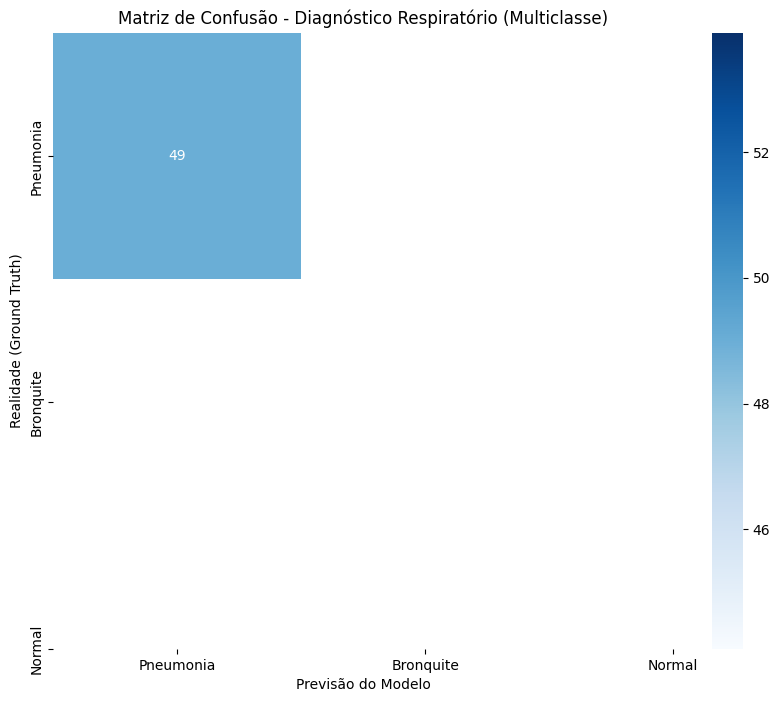


--- Relatório de Classificação Detalhado ---
              precision    recall  f1-score   support

   Pneumonia       0.00      0.00      0.00         0
   Bronquite       1.00      1.00      1.00        49
      Normal       0.00      0.00      0.00         0

    accuracy                           1.00        49
   macro avg       0.33      0.33      0.33        49
weighted avg       1.00      1.00      1.00        49



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Definir os nomes das 3 classes na ordem correta
# Baseado na nossa Célula 5: 0=Pneumonia, 1=Bronquite, 2=Normal
classes = ['Pneumonia', 'Bronquite', 'Normal']

# 2. Obter as previsões
y_pred = model.predict(X_train_final)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_train_final, axis=1)

# 3. Gerar a Matriz de Confusão 3x3
cm = confusion_matrix(y_true, y_pred_classes)

# 4. Plotar o gráfico
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('Matriz de Confusão - Diagnóstico Respiratório (Multiclasse)')
plt.ylabel('Realidade (Ground Truth)')
plt.xlabel('Previsão do Modelo')
plt.show()

# 5. Exibir métricas detalhadas
# O labels=[0, 1, 2] garante que ele procure as 3 classes mesmo que uma não apareça no set
print("\n--- Relatório de Classificação Detalhado ---")
print(classification_report(y_true, y_pred_classes, target_names=classes, labels=[0, 1, 2]))

mostrar mell de bronquite

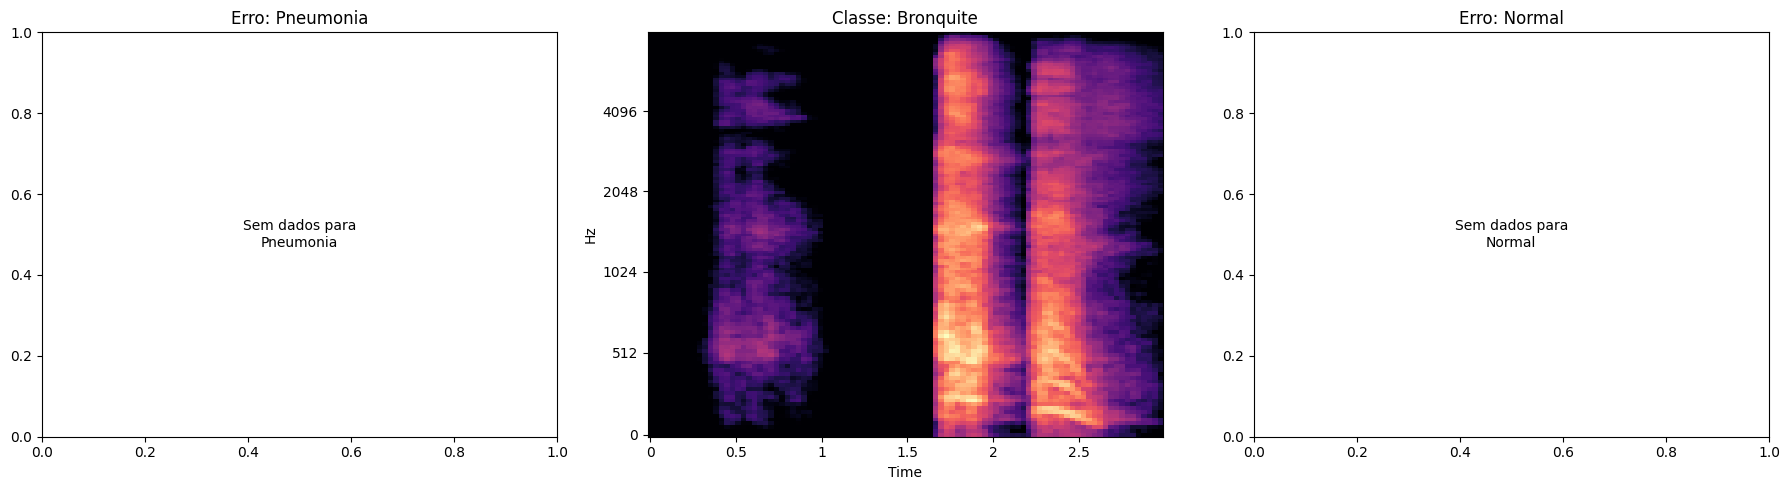

📊 Distribuição atual: 49 amostras totais.


In [22]:
import matplotlib.pyplot as plt
import librosa.display
import numpy as np

# 1. Definir as classes (na ordem das colunas do y_train_final)
classes = ['Pneumonia', 'Bronquite', 'Normal']

# 2. Criar a figura para mostrar os 3 exemplos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, nome_classe in enumerate(classes):
    # Encontrar os índices onde esta classe é verdadeira (1)
    indices = np.where(y_train_final[:, i] == 1)[0]
    
    if len(indices) > 0:
        # Selecionar a primeira amostra encontrada para esta classe
        idx = indices[0]
        img = X_train_final[idx].reshape(128, 94)
        
        # Plotar
        librosa.display.specshow(img, y_axis='mel', x_axis='time', 
                                 sr=16000, ax=axes[i])
        axes[i].set_title(f'Classe: {nome_classe}')
    else:
        axes[i].text(0.5, 0.5, f'Sem dados para\n{nome_classe}', 
                     ha='center', va='center')
        axes[i].set_title(f'Erro: {nome_classe}')

plt.tight_layout()
plt.show()

print(f"📊 Distribuição atual: {len(X_train_final)} amostras totais.")